**RL Algorithm Comparison: DQN, Double DQN, Dueling DQN, IDDQN**

- DQN
- Double DQN
- Dueling DQN
- IDDQN: Double DQN + dueling network + adaptive epsilon + soft target update + optional expert warm-start


In [33]:
import heapq
import math
import random
import time
from collections import deque
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cpu')

In [34]:
# Hyperparameters
@dataclass
class Config:
    grid_size: int = 30 # Defines the maximum number of coordinate for the grid
    start: tuple = (5, 1) # Starting coordinate for the agent
    target: tuple = (14, 29) # Goal coordinate for the agent
    max_steps: int = 160 # Maximum number of steps allowed per episode to agent. Epsidoe ends if this exceeded
    episodes: int = 1000 # Tuneable for further exploration
    gamma: float = 0.90 # Discount factor for Q learning,
    lr: float = 0.0025 # Learning rate
    batch_size: int = 64 # Number of transitions sampled from replay memory per learning update
    memory_size: int = 20_000 # Capacity of replay buffer. Determines how many past transitions are stored for sampling
    target_update: int = 10 # Hard target network update frequency. Every target_update episodes, the target network weights are copied from the current network
    soft_tau: float = 0.02 # Soft update rate for target network in IDDQN
    eps_start: float = 0.90 # Initial epsilon for epsilon-greedy exploration
    eps_end: float = 0.02 # Minimum epsilon, exploration decays toward this floor
    eps_decay: float = 450.0 # Controls decay speed for the IDDQN epsilon schedule. Larger values make epsilon decrease more slowly.
    safe_radius: float = 0.60 # Distance threshold used to detect near obstacle collision
    target_reward: float = 500.0 # Reward for reaching the goal
    collision_penalty: float = -300.0 # Negative reward for hitting the obstacle
    boundary_penalty: float = -300.0 # Penalty for moving out of bounds
    distance_scale: float = -0.02 # Being farther from the target reduces reward
    progress_scale: float = 3.0 # Closer to target gives positive reward
    step_penalty: float = -0.10 # Encourages shorter steps. Larger steps reduces reward
    grad_clip: float = 10.0 # Maximum norm used for gradient clipping. Stabilizes training by preventing very large weight updates

cfg = Config()
CSV_PATH = Path("iddqn_rl_algorithm_metrics.csv")
PLOT_PATH = Path("iddqn_rl_algorithm_paths.png")
BAR_PATH = Path("iddqn_rl_algorithm_bar_comparison.png")
CHECKPOINT_DIR = Path("rl_checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)
cfg

Config(grid_size=30, start=(5, 1), target=(14, 29), max_steps=160, episodes=1000, gamma=0.9, lr=0.0025, batch_size=64, memory_size=20000, target_update=10, soft_tau=0.02, eps_start=0.9, eps_end=0.02, eps_decay=450.0, safe_radius=0.6, target_reward=500.0, collision_penalty=-300.0, boundary_penalty=-300.0, distance_scale=-0.02, progress_scale=3.0, step_penalty=-0.1, grad_clip=10.0)

In [35]:
def add_rect(cells, x0, x1, y0, y1):
    for x in range(x0, x1 + 1):
        for y in range(y0, y1 + 1):
            cells.add((x, y))

# Obstacle map. Tuneable for more complex and more simple use cases
def build_obstacle_map():
    cells = set()
    add_rect(cells, 6, 8, 27, 29)
    add_rect(cells, 6, 11, 23, 24)
    add_rect(cells, 6, 8, 20, 22)
    add_rect(cells, 0, 6, 16, 17)
    add_rect(cells, 13, 16, 23, 25)
    add_rect(cells, 11, 15, 15, 17)
    add_rect(cells, 10, 12, 6, 8)
    add_rect(cells, 15, 17, 2, 7)
    add_rect(cells, 19, 26, 24, 29)
    add_rect(cells, 20, 24, 8, 9)
    add_rect(cells, 24, 29, 12, 14)
    for i in range(7):
        cells.add((18 + i, 21 - i))
        cells.add((24 + i, 15 + i))
    cells.discard(cfg.start)
    cells.discard(cfg.target)
    return cells


OBSTACLES = build_obstacle_map()
len(OBSTACLES)

187

In [36]:
# GridPathPlanningEnv defines RL environment for agent
# Agent has 8 following actions 
# [up, down, left, right, upper right, upper left, down left, down right]
class GridPathPlanningEnv:
    ACTIONS = np.array([
        [0, 1], [0, -1], [-1, 0], [1, 0],
        [1, 1], [1, -1], [-1, 1], [-1, -1],
    ], dtype=np.float32)

    def __init__(self, config, obstacles):
        self.cfg = config
        self.obstacle_cells = set(obstacles)
        self.obstacles = np.array(sorted(obstacles), dtype=np.float32)
        self.start_pos = np.array(config.start, dtype=np.float32)
        self.target_pos = np.array(config.target, dtype=np.float32)
        self.state_size = 4 # 4 state space for agent [x, y, TD, OD], TD: Distance from target, OD: Distance from object
        self.action_size = len(self.ACTIONS)
        self.reset()

    # reset() func reset agent position to starting position
    # Clears step count, returns initial normalized state
    def reset(self):
        self.pos = self.start_pos.copy()
        self.steps = 0
        self.done = False
        self.path = [tuple(map(int, self.pos))]
        return self._state()

    # Calculating distance from target in L2 norm
    def _target_distance(self, pos=None):
        p = self.pos if pos is None else np.array(pos, dtype=np.float32)
        return float(np.linalg.norm(p - self.target_pos))

    # Calcualting distance from obstalce in L2 norm 
    def _obstacle_distance(self, pos=None):
        p = self.pos if pos is None else np.array(pos, dtype=np.float32)
        return float(np.min(np.linalg.norm(self.obstacles - p, axis=1)))

    # state() returns 4 state
    # Normalized x position
    # Normalized y position
    # Normalized distance to target
    # Normalized distance to nearest obstacle
    def _state(self):
        max_dist = math.sqrt(2) * self.cfg.grid_size
        od = min(self._obstacle_distance(), max_dist)
        return np.array([
            self.pos[0] / self.cfg.grid_size,
            self.pos[1] / self.cfg.grid_size,
            self._target_distance() / max_dist,
            od / max_dist,
        ], dtype=np.float32)

    # Applies action to current position
    # It calculates out-of-bounds, collision, reaching target, distance-based reward of agent
    # It returns next_state, reward, done (if the exploration is successfull or not) and
    # info having target_distance, object_distance, reached, collision, out of bounds
    def step(self, action):
        if self.done:
            return self._state(), 0.0, True, {}

        previous_td = self._target_distance()
        proposed = self.pos + self.ACTIONS[action]
        self.steps += 1

        out = proposed[0] < 0 or proposed[0] > self.cfg.grid_size or proposed[1] < 0 or proposed[1] > self.cfg.grid_size
        self.pos = proposed
        self.path.append(tuple(map(int, self.pos)))

        td = self._target_distance() 
        od = self._obstacle_distance()
        reached = td <= math.sqrt(2) / 2
        collision = tuple(map(int, self.pos)) in self.obstacle_cells or od < self.cfg.safe_radius

        # Reward for RL agent
        reward = self.cfg.step_penalty + self.cfg.distance_scale * td + self.cfg.progress_scale * (previous_td - td)
        if reached:
            reward += self.cfg.target_reward
        if collision:
            reward += self.cfg.collision_penalty
        if out:
            reward += self.cfg.boundary_penalty

        self.done = bool(reached or collision or out or self.steps >= self.cfg.max_steps)
        info = {"target_distance": td, "obstacle_distance": od, "reached": reached, "collision": collision, "out_of_bounds": out}
        return self._state(), float(reward), self.done, info


env = GridPathPlanningEnv(cfg, OBSTACLES)
env.reset(), env.state_size, env.action_size

(array([0.16666667, 0.03333334, 0.69322115, 0.16666667], dtype=float32), 4, 8)

In [37]:
# A standard fully connected Q-network
# ReLU() activation function is being utilized with state_size 4 and action_size 8
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, action_size),
        )

    def forward(self, x):
        return self.net(x)


# Duelling Q Network architecture, it comprises of
# Common feature extractor
# Value stream producing a scaler state value
# Advantage stream producing per-action advantages
# It returns combined output having value + advantage - mean of both
# This is further used by Dueling DQN and IDDQN
class DuelingQNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(state_size, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
        )
        self.value = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 1))
        self.advantage = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, action_size))

    def forward(self, x):
        z = self.feature(x)
        value = self.value(z)
        advantage = self.advantage(z)
        return value + advantage - advantage.mean(dim=1, keepdim=True)

# ReplayBuffer class stores transitions
# Replay helps break correlation between sequential steps and improves learning stability
class ReplayBuffer:
    def __init__(self, capacity):
        self.data = deque(maxlen=capacity)

    def __len__(self):
        return len(self.data)

    def push(self, state, action, reward, next_state, done):
        self.data.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.data, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.tensor(np.array(states), dtype=torch.float32, device=DEVICE),
            torch.tensor(actions, dtype=torch.long, device=DEVICE).unsqueeze(1),
            torch.tensor(rewards, dtype=torch.float32, device=DEVICE).unsqueeze(1),
            torch.tensor(np.array(next_states), dtype=torch.float32, device=DEVICE),
            torch.tensor(dones, dtype=torch.float32, device=DEVICE).unsqueeze(1),
        )

In [38]:
# RLAgent handles network creation, action selection, learning, target updates
class RLAgent:
    def __init__(self, state_size, action_size, config, algorithm):
        self.cfg = config
        self.algorithm = algorithm
        self.action_size = action_size
        use_dueling = algorithm in {"Dueling DQN", "IDDQN"} # 'DuelingQNetwork' for 'Dueling DQN' and 'IDDQN'
        net_cls = DuelingQNetwork if use_dueling else QNetwork
        self.current_net = net_cls(state_size, action_size).to(DEVICE)
        self.target_net = net_cls(state_size, action_size).to(DEVICE)
        self.target_net.load_state_dict(self.current_net.state_dict()) # target_net initialized to current_net
        self.target_net.eval()
        self.memory = ReplayBuffer(config.memory_size)
        self.optimizer = optim.Adam(self.current_net.parameters(), lr=config.lr) # Base paper used Adam optimizer
        self.loss_fn = nn.MSELoss()

    # Configuration with epsilon only for IDDQN learning process
    # IDDQN uses adaptive epsilon-greedy policy
    # This controls the probability of random action vs greedy action
    def epsilon(self, episode):
        if self.algorithm == "IDDQN":
            return self.cfg.eps_end + (self.cfg.eps_start - self.cfg.eps_end) / (1.0 + math.exp(episode / self.cfg.eps_decay))
        decay = max(0.05, self.cfg.eps_start * (0.995 ** episode))
        return max(self.cfg.eps_end, decay)

    # Condition of exploration and exploitation for adaptive epsilon-greedy policy
    def act(self, state, episode=10_000, greedy=False):
        eps = 0.0 if greedy else self.epsilon(episode)
        if random.random() < eps:
            return random.randrange(self.action_size)
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            return int(self.current_net(s).argmax(dim=1).item())
    
    # Learning process of agent in exploration and exploitation 
    def learn(self):
        if len(self.memory) < self.cfg.batch_size:
            return None
        states, actions, rewards, next_states, dones = self.memory.sample(self.cfg.batch_size) # Samples a batch
        q_values = self.current_net(states).gather(1, actions) # Computs current Q values for choosen actions
        
        # Later it computes next actions and next Q values
        with torch.no_grad():
            if self.algorithm in {"Double DQN", "IDDQN"}:
                next_actions = self.current_net(next_states).argmax(dim=1, keepdim=True)
                next_q = self.target_net(next_states).gather(1, next_actions)
            else:
                next_q = self.target_net(next_states).max(dim=1, keepdim=True).values
            target = rewards + self.cfg.gamma * next_q * (1.0 - dones) # The ground truth target value
        loss = self.loss_fn(q_values, target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.current_net.parameters(), self.cfg.grad_clip)
        self.optimizer.step()
        return float(loss.item())

    # Updating target
    # If soft = False, hard copy target = current
    # If soft = True, tau becomes soft_tau and updates the target
    def update_target(self, soft=False):
        if soft:
            tau = self.cfg.soft_tau
            for target_param, current_param in zip(self.target_net.parameters(), self.current_net.parameters()):
                target_param.data.copy_(tau * current_param.data + (1.0 - tau) * target_param.data)
        else:
            self.target_net.load_state_dict(self.current_net.state_dict())

# So technically,
# DQN uses hard target update
# IDDQN can use soft updates each step

In [39]:
#  TODO: Also check without warm-satrt, if it's working well or not

# A* path used as a warm-start and imitation support
# astar_path() builds a shortest collision-free path around obstacles
# It uses Euclidean heuristic
def astar_path(start=cfg.start, target=cfg.target):
    obstacles = set(OBSTACLES)
    actions = [tuple(map(int, a)) for a in GridPathPlanningEnv.ACTIONS]

    def h(cell):
        return math.hypot(cell[0] - target[0], cell[1] - target[1])

    queue = [(h(start), 0.0, start)]
    came_from = {start: None}
    cost_so_far = {start: 0.0}
    while queue:
        _, cost, current = heapq.heappop(queue)
        if current == target:
            break
        for dx, dy in actions:
            nxt = (current[0] + dx, current[1] + dy)
            if nxt[0] < 0 or nxt[0] > cfg.grid_size or nxt[1] < 0 or nxt[1] > cfg.grid_size or nxt in obstacles:
                continue
            new_cost = cost + math.hypot(dx, dy)
            if new_cost < cost_so_far.get(nxt, float("inf")):
                cost_so_far[nxt] = new_cost
                came_from[nxt] = current
                heapq.heappush(queue, (new_cost + h(nxt), new_cost, nxt))
    if target not in came_from:
        return []
    path = []
    cell = target
    while cell is not None:
        path.append(cell)
        cell = came_from[cell]
    return path[::-1]

# expert_transitions() hels to converts the expert path into state-action transitions
def expert_transitions(env, path):
    action_lookup = {tuple(map(int, action)): idx for idx, action in enumerate(env.ACTIONS)}
    transitions = []
    state = env.reset()
    for current, nxt in zip(path[:-1], path[1:]):
        action = action_lookup[(nxt[0] - current[0], nxt[1] - current[1])]
        next_state, reward, done, _ = env.step(action)
        transitions.append((state, action, reward, next_state, done))
        state = next_state
        if done:
            break
    return transitions

# Fills replay memory with repetated expert transitions
# This gives agent useful examples before training
def prefill_replay(env, agent, path, repeats=50):
    transitions = expert_transitions(env, path)
    for _ in range(repeats):
        for transition in transitions:
            agent.memory.push(*transition)


# Trains the network directly via supervised classification on expert actions
# So that the agent learns efficiently and do well
# Technically this warm-start only used for IDDQN (review TODO)

# This essentially makes agent to clone the A* path
def behavior_clone(env, agent, path, epochs=200):
    transitions = expert_transitions(env, path)
    if not transitions:
        return None
    states = torch.tensor(np.array([t[0] for t in transitions]), dtype=torch.float32, device=DEVICE)
    actions = torch.tensor([t[1] for t in transitions], dtype=torch.long, device=DEVICE)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        logits = agent.current_net(states)
        loss = loss_fn(logits, actions)
        agent.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(agent.current_net.parameters(), agent.cfg.grad_clip)
        agent.optimizer.step()
    agent.target_net.load_state_dict(agent.current_net.state_dict())
    return float(loss.item())


expert_path = astar_path()
len(expert_path) - 1

28

In [40]:
# Main training code for agent in ALGORITHMS
# In history it will store reward, steps, success, loss for each agent
def train_agent(env, agent, episodes=None, verbose_every=100):
    episodes = episodes or env.cfg.episodes
    history = {"reward": [], "steps": [], "success": [], "loss": []}
    for episode in range(episodes):
        state = env.reset() # For each episode, it creates a fresh environment
        total_reward = 0.0
        losses = []
        final_info = {}
        for _ in range(env.cfg.max_steps):
            action = agent.act(state, episode)
            next_state, reward, done, info = env.step(action)
            agent.memory.push(state, action, reward, next_state, done)
            loss = agent.learn()
            if loss is not None:
                losses.append(loss)
            if agent.algorithm == "IDDQN":
                agent.update_target(soft=True)
            state = next_state
            total_reward += reward
            final_info = info
            if done:
                break
        if agent.algorithm != "IDDQN" and episode % env.cfg.target_update == 0:
            agent.update_target(soft=False)
        history["reward"].append(total_reward)
        history["steps"].append(env.steps)
        history["success"].append(bool(final_info.get("reached", False)))
        history["loss"].append(float(np.mean(losses)) if losses else np.nan)
        if verbose_every and (episode + 1) % verbose_every == 0:
            print(f"{agent.algorithm:12s} | episode {episode + 1:4d}/{episodes} | reward {total_reward:8.2f} | recent success {np.mean(history['success'][-verbose_every:]):.2f}")
    return history

# After training it runs greedy_rollout()
# This performs a deterministic evaluation run
# It always chooses greedy action and records 
# Path, total reward, final info, inference time (TODO: Also make comparision for inference time, will be a good point)
def greedy_rollout(env, agent):
    start_time = time.perf_counter()
    state = env.reset()
    total_reward = 0.0
    final_info = {}
    for _ in range(env.cfg.max_steps):
        action = agent.act(state, greedy=True)
        state, reward, done, info = env.step(action)
        total_reward += reward
        final_info = info
        if done:
            break
    elapsed_ms = (time.perf_counter() - start_time) * 1000
    return list(env.path), total_reward, final_info, elapsed_ms


In [41]:

# Set RUN_TRAINING=False if you only want to load existing checkpoints.
RUN_TRAINING = True
USE_EXPERT_WARMSTART = True
ALGORITHMS = ["DQN", "Double DQN", "Dueling DQN", "IDDQN"]

agents = {}
histories = {}
paths = {}
rollout_info = {}
rollout_rewards = {}
inference_times = {}

for algorithm in ALGORITHMS:
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    local_env = GridPathPlanningEnv(cfg, OBSTACLES)
    agent = RLAgent(local_env.state_size, local_env.action_size, cfg, algorithm)
    checkpoint_path = CHECKPOINT_DIR / f"{algorithm.replace(' ', '_').lower()}.pth"

    if RUN_TRAINING:
        if USE_EXPERT_WARMSTART:
            prefill_replay(local_env, agent, expert_path, repeats=40)
        if algorithm == "IDDQN":
            behavior_clone(local_env, agent, expert_path, epochs=300)
        histories[algorithm] = train_agent(local_env, agent, episodes=cfg.episodes, verbose_every=100)
        if algorithm == "IDDQN":
            behavior_clone(local_env, agent, expert_path, epochs=300)
        torch.save(agent.current_net.state_dict(), checkpoint_path)
    elif checkpoint_path.exists():
        agent.current_net.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
        agent.target_net.load_state_dict(agent.current_net.state_dict())
    else:
        raise FileNotFoundError(f"Missing checkpoint: {checkpoint_path}")

    path, reward, info, elapsed_ms = greedy_rollout(local_env, agent)
    agents[algorithm] = agent
    paths[algorithm] = path
    rollout_info[algorithm] = info
    rollout_rewards[algorithm] = reward
    inference_times[algorithm] = elapsed_ms

{name: {"steps": len(path) - 1, "reached": rollout_info[name].get("reached", False)} for name, path in paths.items()}

DQN          | episode  100/1000 | reward  -290.46 | recent success 0.00
DQN          | episode  200/1000 | reward  -279.00 | recent success 0.00
DQN          | episode  300/1000 | reward  -253.07 | recent success 0.05
DQN          | episode  400/1000 | reward   558.42 | recent success 0.23
DQN          | episode  500/1000 | reward   571.57 | recent success 0.38
DQN          | episode  600/1000 | reward   576.26 | recent success 0.64
DQN          | episode  700/1000 | reward  -259.14 | recent success 0.83
DQN          | episode  800/1000 | reward   574.92 | recent success 0.90
DQN          | episode  900/1000 | reward   564.34 | recent success 0.91
DQN          | episode 1000/1000 | reward   577.03 | recent success 0.93
Double DQN   | episode  100/1000 | reward  -304.01 | recent success 0.00
Double DQN   | episode  200/1000 | reward  -260.45 | recent success 0.01
Double DQN   | episode  300/1000 | reward  -241.54 | recent success 0.06
Double DQN   | episode  400/1000 | reward   556.13 

{'DQN': {'steps': 28, 'reached': True},
 'Double DQN': {'steps': 28, 'reached': True},
 'Dueling DQN': {'steps': 160, 'reached': False},
 'IDDQN': {'steps': 28, 'reached': True}}

In [42]:
def path_length(path):
    return float(sum(math.hypot(b[0] - a[0], b[1] - a[1]) for a, b in zip(path[:-1], path[1:]))) if len(path) > 1 else 0.0


def count_corners(path):
    if len(path) < 3:
        return 0
    directions = [(b[0] - a[0], b[1] - a[1]) for a, b in zip(path[:-1], path[1:])]
    return int(sum(directions[i] != directions[i - 1] for i in range(1, len(directions))))


def min_obstacle_distance(path):
    if not path:
        return 0.0
    obs = np.array(sorted(OBSTACLES), dtype=np.float32)
    pts = np.array(path, dtype=np.float32)
    return float(np.min(np.linalg.norm(pts[:, None, :] - obs[None, :, :], axis=2)))


rows = []
for algorithm in ALGORITHMS:
    path = paths[algorithm]
    info = rollout_info[algorithm]
    rows.append({
        "algorithm": algorithm,
        "reward": round(rollout_rewards[algorithm], 4),
        "steps": len(path) - 1,
        "target_distance": round(float(info.get("target_distance", math.inf)), 4),
        "obstacle_distance": round(min_obstacle_distance(path), 4),
        "path_length": round(path_length(path), 4),
        "corners": count_corners(path),
        "inference_time_ms": round(inference_times[algorithm], 4),
        "reached": bool(info.get("reached", False)),
    })

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(CSV_PATH, index=False)
metrics_df

,algorithm,reward,steps,target_distance,obstacle_distance,path_length,corners,inference_time_ms,reached
0,DQN,577.4160,28,0.0000,1.0,33.3848,16,6.9907,True
1,Double DQN,576.8803,28,0.0000,1.0,37.5269,9,4.6026,True
2,Dueling DQN,19.8326,160,8.0623,1.0,187.3381,152,41.7813,False
3,IDDQN,577.3767,28,0.0000,1.0,31.7279,11,9.4238,True


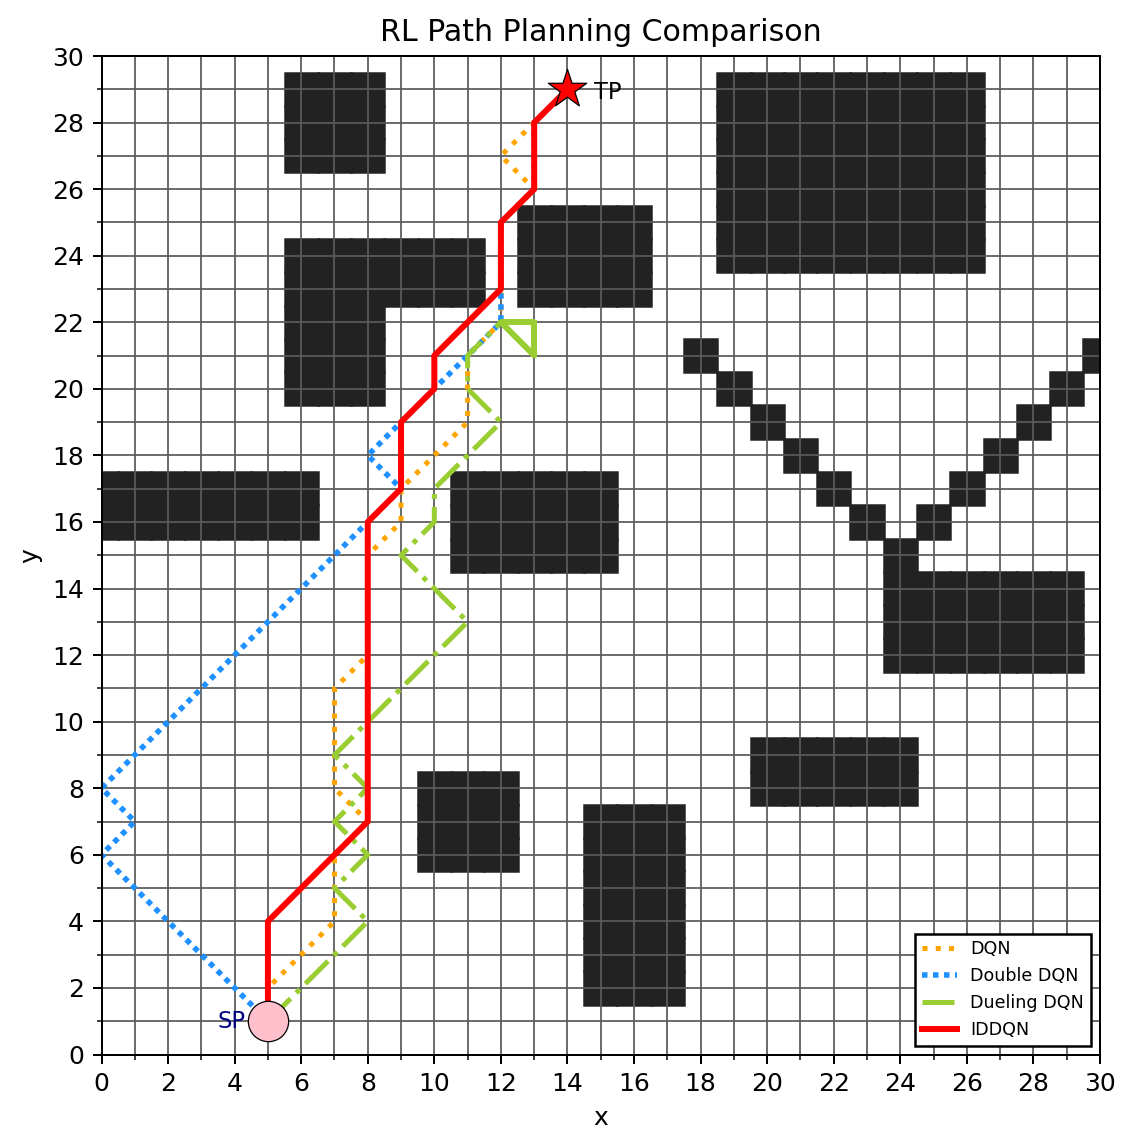

In [43]:
STYLE = {
    "DQN": {"color": "orange", "linestyle": ":", "linewidth": 2.0},
    "Double DQN": {"color": "dodgerblue", "linestyle": (0, (1, 1)), "linewidth": 2.2},
    "Dueling DQN": {"color": "yellowgreen", "linestyle": "-.", "linewidth": 2.0},
    "IDDQN": {"color": "red", "linestyle": "-", "linewidth": 2.4},
}


def plot_rl_paths(paths, save_path=PLOT_PATH):
    fig, ax = plt.subplots(figsize=(6.4, 6.4), dpi=180)
    ax.set_xlim(0, cfg.grid_size)
    ax.set_ylim(0, cfg.grid_size)
    ax.set_aspect("equal")
    ax.set_xticks(np.arange(0, cfg.grid_size + 1, 2))
    ax.set_yticks(np.arange(0, cfg.grid_size + 1, 2))
    ax.set_xticks(np.arange(0, cfg.grid_size + 1, 1), minor=True)
    ax.set_yticks(np.arange(0, cfg.grid_size + 1, 1), minor=True)
    ax.grid(which="both", color="#5a5a5a", linewidth=0.7)

    for x, y in OBSTACLES:
        ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, facecolor="#222222", edgecolor="#222222"))

    for algorithm in ALGORITHMS:
        path = np.array(paths[algorithm], dtype=float)
        if len(path) > 0:
            ax.plot(path[:, 0], path[:, 1], label=algorithm, **STYLE[algorithm])

    ax.scatter(*cfg.start, marker="o", s=260, c="pink", edgecolor= "black", linewidth=0.5,zorder=6)
    ax.scatter(*cfg.target, marker="*", s=260, c="red", edgecolor="black", linewidth=0.5, zorder=6)
    ax.text(cfg.start[0] - 1.5, cfg.start[1] - 0.2, "SP", fontsize=9, color="navy")
    ax.text(cfg.target[0] + 0.8, cfg.target[1] - 0.3, "TP", fontsize=9, color="black")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("RL Path Planning Comparison")
    ax.legend(loc="lower right", frameon=True, fancybox=False, framealpha=1.0, edgecolor="black", fontsize=7)
    fig.tight_layout(pad=0.8)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    return fig, ax


plot_rl_paths(paths);

In [44]:
# Read CSV back for publication plots.
comparison_df = pd.read_csv(CSV_PATH)
comparison_df

,algorithm,reward,steps,target_distance,obstacle_distance,path_length,corners,inference_time_ms,reached
0,DQN,577.4160,28,0.0000,1.0,33.3848,16,6.9907,True
1,Double DQN,576.8803,28,0.0000,1.0,37.5269,9,4.6026,True
2,Dueling DQN,19.8326,160,8.0623,1.0,187.3381,152,41.7813,False
3,IDDQN,577.3767,28,0.0000,1.0,31.7279,11,9.4238,True


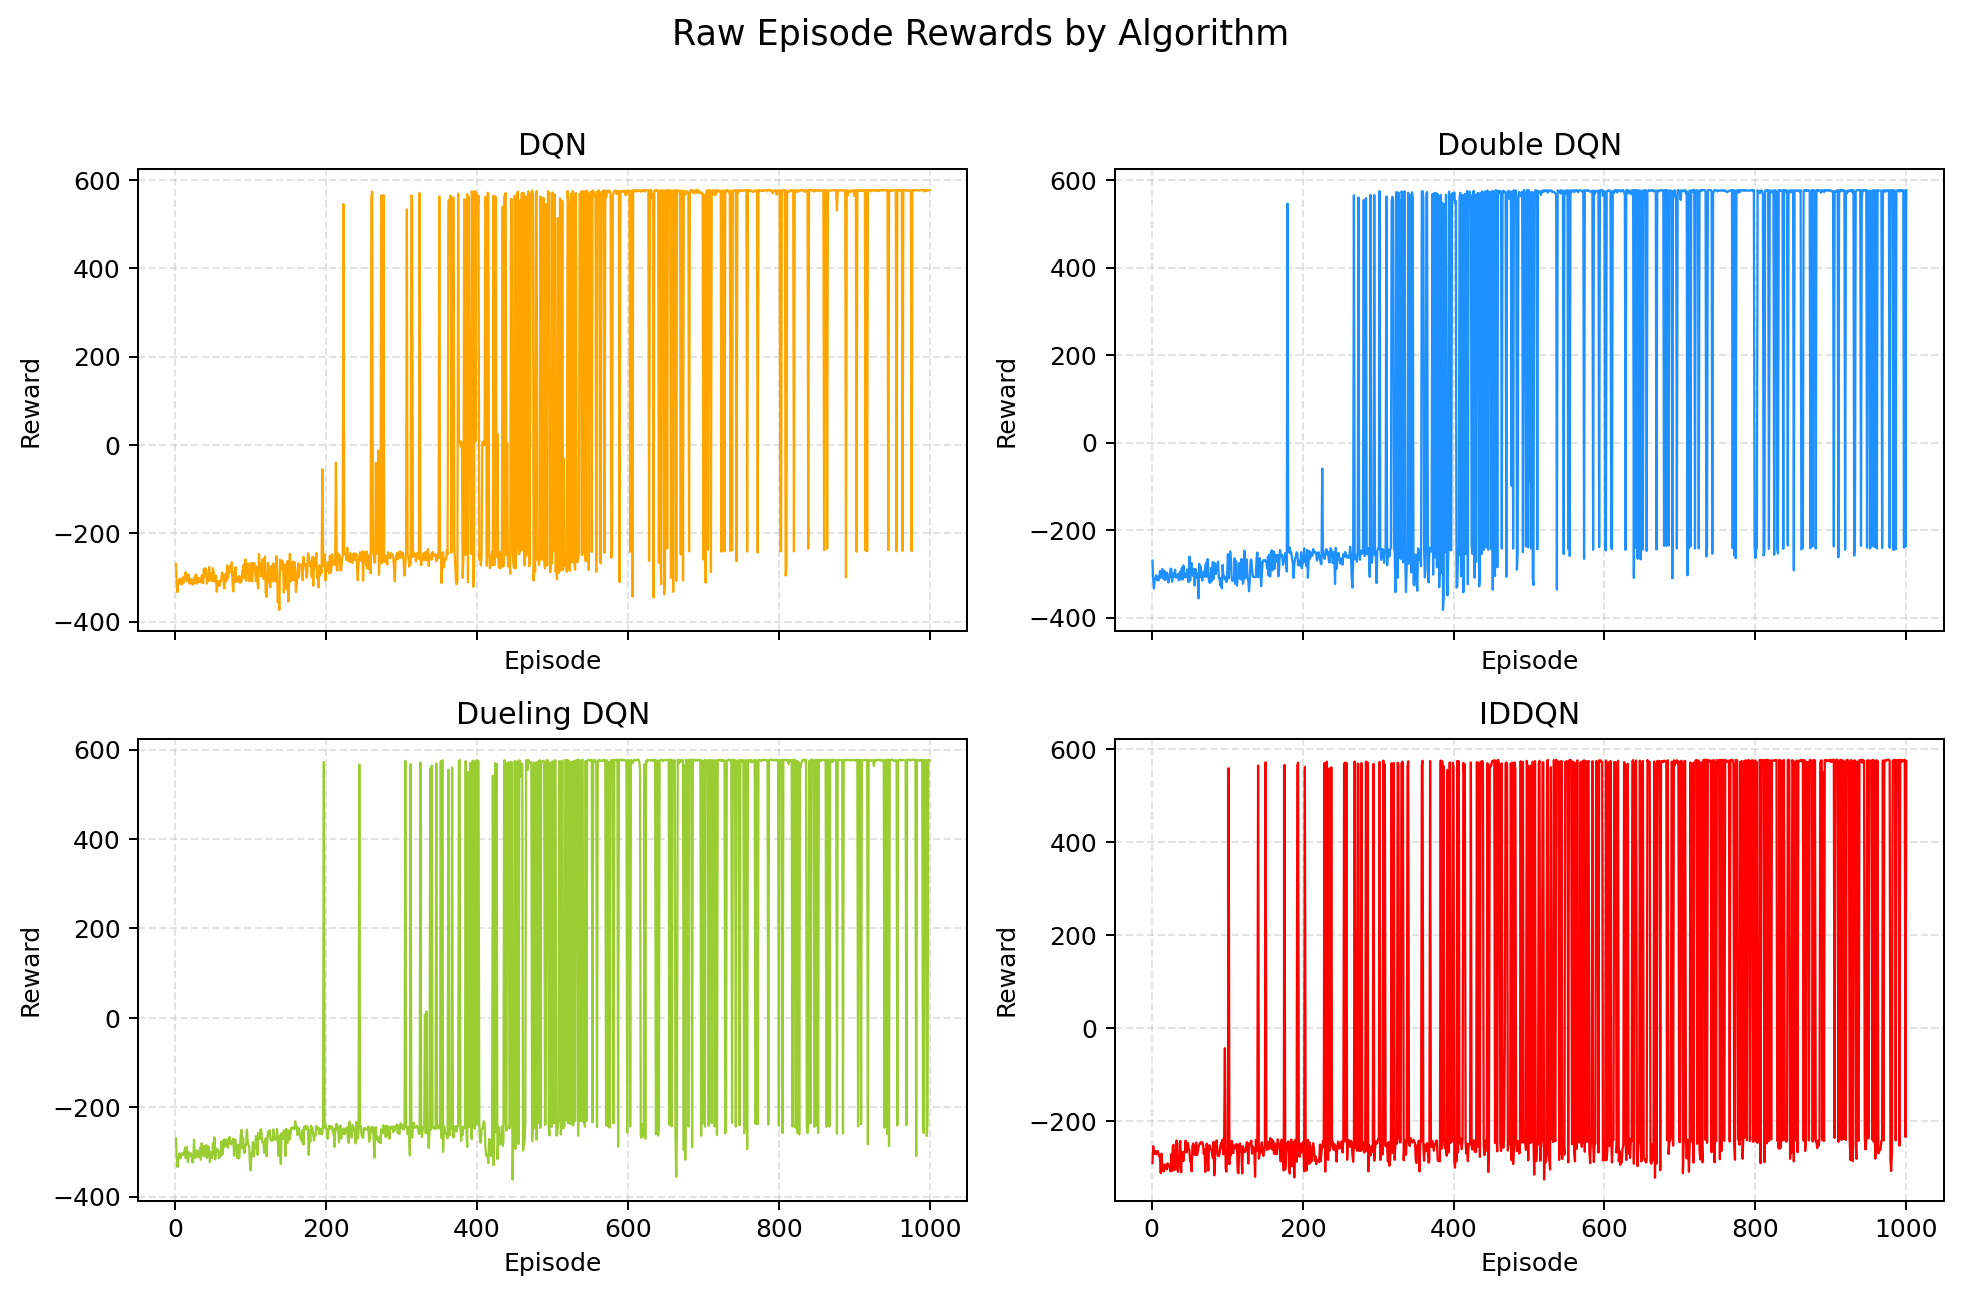

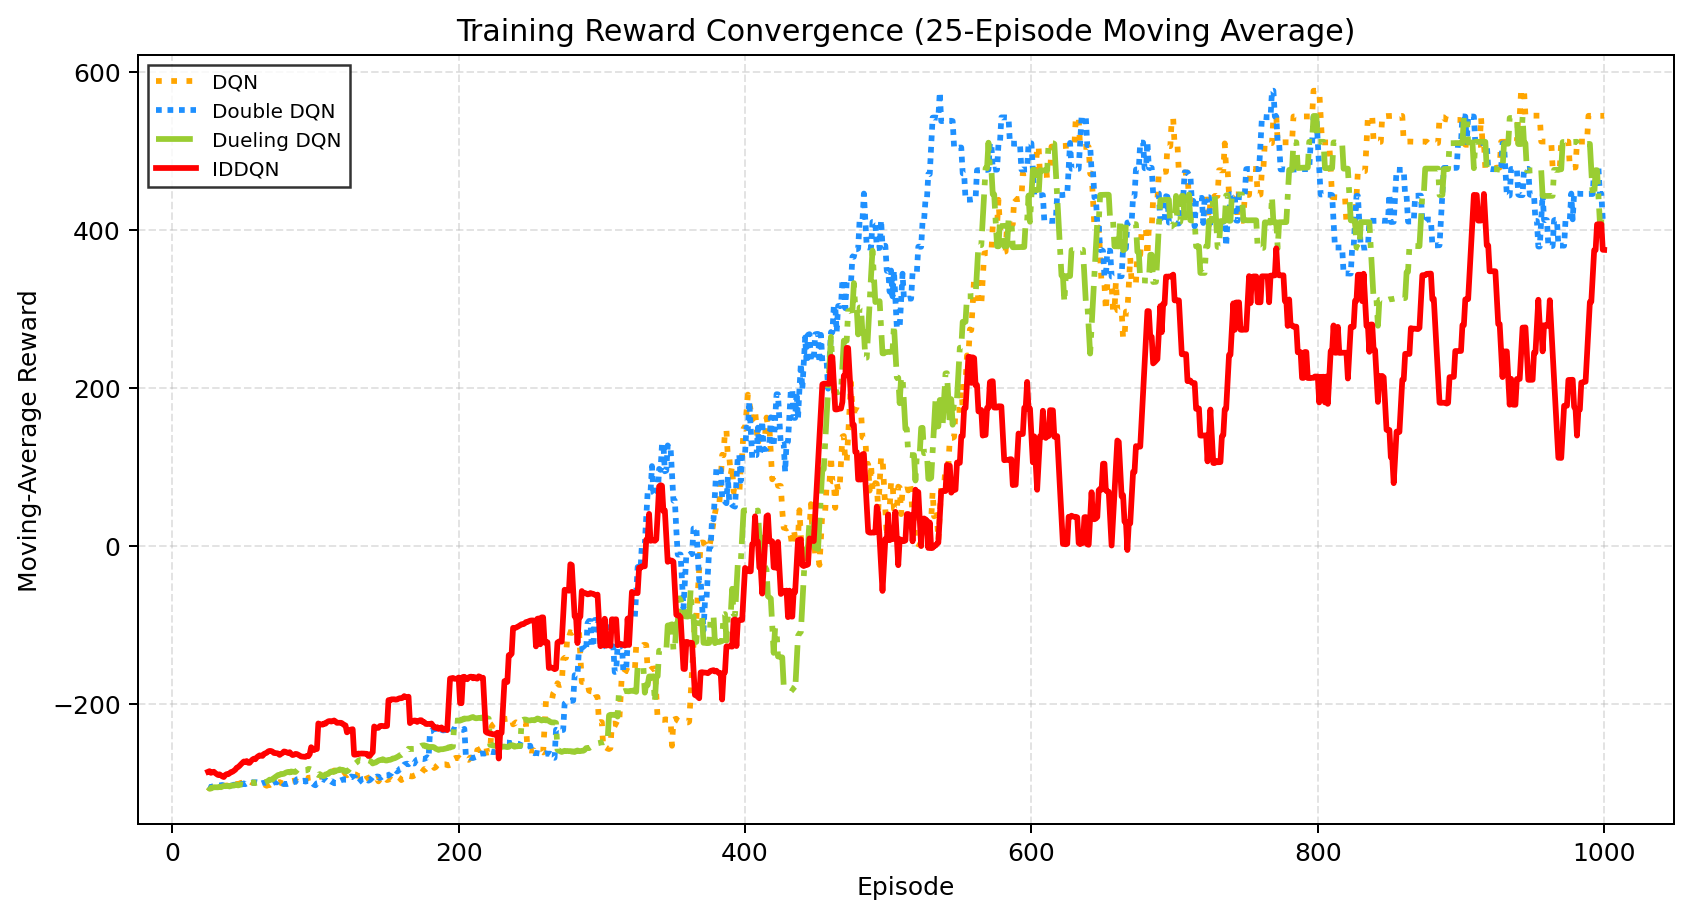

Saved reward history CSV to: C:\Users\USER\AFO\iddqn_rl_episode_rewards.csv
Saved raw reward subplot figure to: C:\Users\USER\AFO\iddqn_rl_episode_reward_raw_subplots.png
Saved moving-average reward figure to: C:\Users\USER\AFO\iddqn_rl_episode_reward_moving_average.png


In [45]:
# Episodes vs reward plots for all RL algorithms.
# Run this after the main training/comparison cell so `histories` is available.
def moving_average(values, window=25):
    values = np.asarray(values, dtype=float)
    if len(values) < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")

if "histories" not in globals() or not histories:
    raise RuntimeError("Run the main training/comparison cell first so histories are available.")

reward_rows = []
for algorithm in ALGORITHMS:
    rewards = histories[algorithm]["reward"]
    for episode, reward in enumerate(rewards, start=1):
        reward_rows.append({"algorithm": algorithm, "episode": episode, "reward": reward})

reward_history_df = pd.DataFrame(reward_rows)
REWARD_HISTORY_CSV = Path("iddqn_rl_episode_rewards.csv")
RAW_REWARD_SUBPLOTS_PATH = Path("iddqn_rl_episode_reward_raw_subplots.png")
MA_REWARD_CURVE_PATH = Path("iddqn_rl_episode_reward_moving_average.png")
reward_history_df.to_csv(REWARD_HISTORY_CSV, index=False)

# 1) Separate raw/faint reward plot for each algorithm.
fig, axes = plt.subplots(2, 2, figsize=(11, 7), dpi=180, sharex=True)
axes = axes.ravel()
for ax, algorithm in zip(axes, ALGORITHMS):
    rewards = np.asarray(histories[algorithm]["reward"], dtype=float)
    episodes = np.arange(1, len(rewards) + 1)
    ax.plot(episodes, rewards, color=STYLE[algorithm]["color"], alpha=1, linewidth=0.9)
    ax.set_title(algorithm)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Reward")
    ax.grid(True, linestyle="--", alpha=0.35)
fig.suptitle("Raw Episode Rewards by Algorithm", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(RAW_REWARD_SUBPLOTS_PATH, dpi=300, bbox_inches="tight")
plt.show()

# 2) Clean moving-average comparison only. No faint/raw lines here.
fig, ax = plt.subplots(figsize=(9.5, 5.2), dpi=180)
window = 25
for algorithm in ALGORITHMS:
    rewards = np.asarray(histories[algorithm]["reward"], dtype=float)
    episodes = np.arange(1, len(rewards) + 1)
    smooth = moving_average(rewards, window=window)
    smooth_episodes = np.arange(window, len(rewards) + 1) if len(rewards) >= window else episodes
    ax.plot(
        smooth_episodes,
        smooth,
        label=f"{algorithm}",
        color=STYLE[algorithm]["color"],
        linestyle=STYLE[algorithm]["linestyle"],
        linewidth=2.3,
    )

ax.set_title(f"Training Reward Convergence ({window}-Episode Moving Average)")
ax.set_xlabel("Episode")
ax.set_ylabel("Moving-Average Reward")
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(frameon=True, fancybox=False, edgecolor="black", fontsize=8)
fig.tight_layout()
fig.savefig(MA_REWARD_CURVE_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved reward history CSV to: {REWARD_HISTORY_CSV.resolve()}")
print(f"Saved raw reward subplot figure to: {RAW_REWARD_SUBPLOTS_PATH.resolve()}")
print(f"Saved moving-average reward figure to: {MA_REWARD_CURVE_PATH.resolve()}")


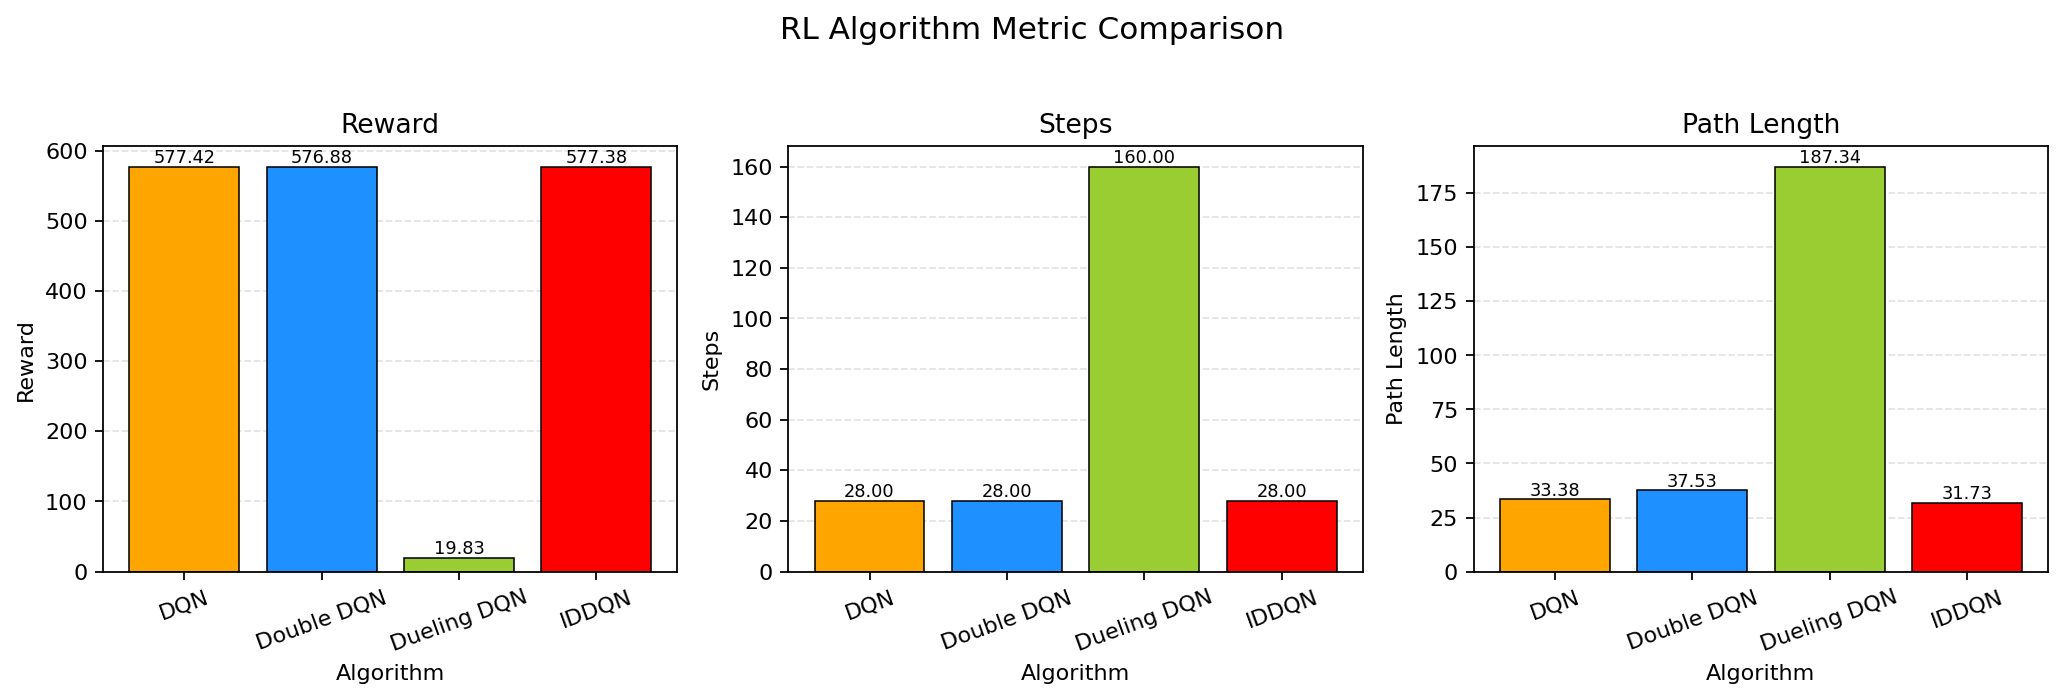

In [46]:
def plot_metric_bars(df, save_path=BAR_PATH):
    metrics = [("reward", "Reward"), ("steps", "Steps"), ("path_length", "Path Length")]
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), dpi=160)
    colors = [STYLE[name]["color"] for name in df["algorithm"]]
    for ax, (metric, title) in zip(axes, metrics):
        bars = ax.bar(df["algorithm"], df[metric], color=colors, edgecolor="black", linewidth=0.7)
        ax.set_title(title)
        ax.set_xlabel("Algorithm")
        ax.set_ylabel(title)
        ax.tick_params(axis="x", rotation=20)
        ax.grid(axis="y", linestyle="--", alpha=0.35)
        ax.set_axisbelow(True)
        for bar, value in zip(bars, df[metric]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value:.2f}", ha="center", va="bottom", fontsize=8)
    fig.suptitle("RL Algorithm Metric Comparison", fontsize=14, y=1.03)
    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    return fig, axes


plot_metric_bars(comparison_df);

(<Figure size 2080x672 with 2 Axes>,
 array([<Axes: title={'center': 'Corners'}, xlabel='Algorithm', ylabel='Corners'>,
        <Axes: title={'center': 'Inference Time'}, xlabel='Algorithm', ylabel='Inference Time'>],
       dtype=object))

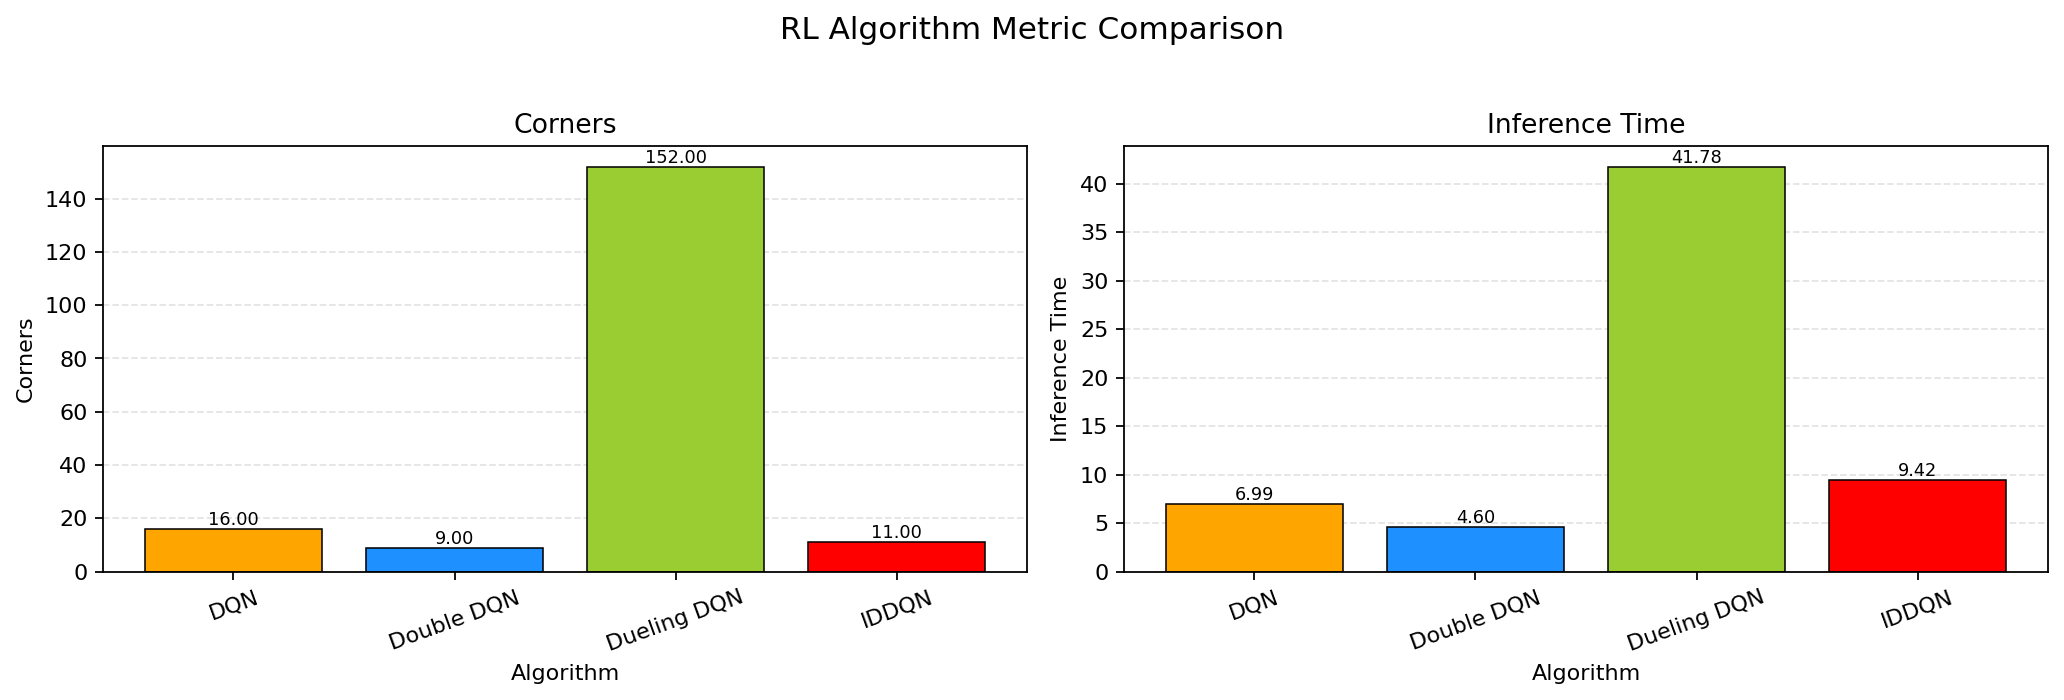

In [47]:
def plot_metric_bars(df, save_path=BAR_PATH):
    metrics = [("corners", "Corners"), ("inference_time_ms", "Inference Time")]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), dpi=160)
    colors = [STYLE[name]["color"] for name in df["algorithm"]]
    for ax, (metric, title) in zip(axes, metrics):
        bars = ax.bar(df["algorithm"], df[metric], color=colors,
                      edgecolor="black", linewidth=0.7)
        ax.set_title(title)
        ax.set_xlabel("Algorithm")
        ax.set_ylabel(title)
        ax.tick_params(axis="x", rotation=20)
        ax.grid(axis="y", linestyle="--", alpha=0.35)
        ax.set_axisbelow(True)
        for bar, value in zip(bars, df[metric]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{value:.2f}", ha="center", va="bottom", fontsize=8)
    fig.suptitle("RL Algorithm Metric Comparison", fontsize=14, y=1.03)
    fig.tight_layout()
    # fig.savefig(save_path, dpi=300, bbox_inches="tight")
    return fig, axes


plot_metric_bars(comparison_df)

In [ ]:
# TODO: create a .ipynb file named 'IDDQN_Algorithm_comparison.ipynb' and compare all classic algorithm like A*, RRT, RRT*, APF etc.